# 01 - Data Exploration & Skills Taxonomy Grounding

This notebook explores the bundled resume corpus (`backend/data/raw/Resume.csv`,
a trimmed copy of the Kaggle "Resume Dataset" by snehaanbhawal) and uses it to
**ground** the skills taxonomy in `backend/app/data/skills_taxonomy.json` in
real resume text, rather than a list invented purely from memory.

The dataset's resumes follow a consistent template with a `Skills` section
listing comma-separated skill phrases - we parse those sections directly to
find out which skills recruiters/candidates in this dataset actually use.

In [1]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../backend/data/raw/Resume.csv")
print(f"{len(df)} resumes, {df['Category'].nunique()} categories")
df.head(2)

2484 resumes, 24 categories


,ID,Resume_str,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...",HR


## Category distribution

How many resumes does each job category have?

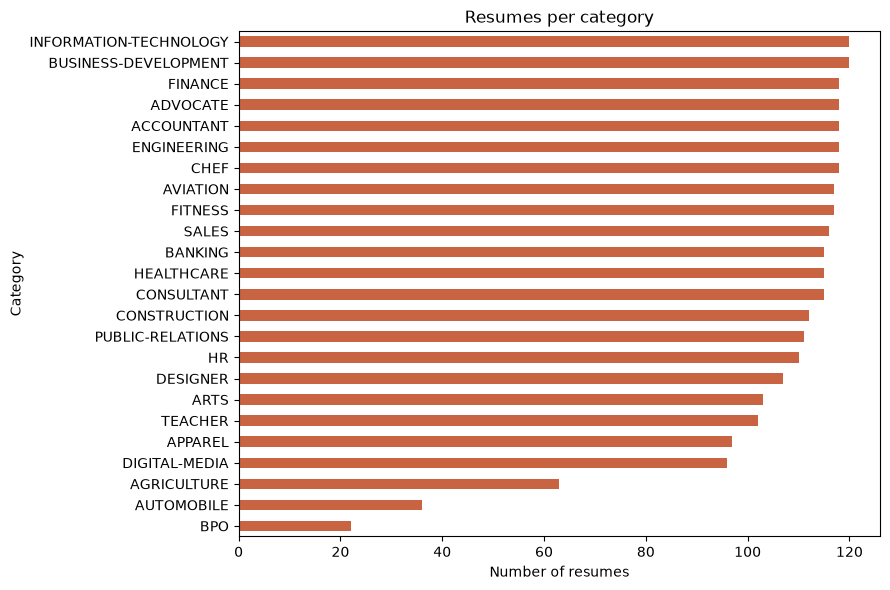

In [2]:
category_counts = df["Category"].value_counts()

fig, ax = plt.subplots(figsize=(9, 6))
category_counts.sort_values().plot(kind="barh", ax=ax, color="#c96442")
ax.set_xlabel("Number of resumes")
ax.set_title("Resumes per category")
plt.tight_layout()
plt.show()

Categories range from 22 resumes (BPO) to 120 (Information Technology /
Business Development). The ten curated job roles in
`backend/app/data/curated_jobs.json` were deliberately chosen from the
higher-count categories (100+ resumes), so the sample-resume picker and the
ranking sanity checks have enough real examples to be meaningful.

## Resume length

A quick sanity check on text length - very short "resumes" would be a data
quality problem worth knowing about before building a pipeline on top of
this corpus.

count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: Resume_str, dtype: float64


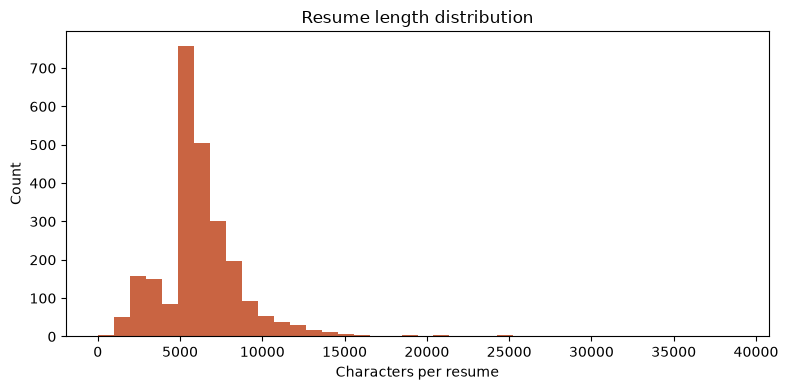

In [3]:
lengths = df["Resume_str"].str.len()
print(lengths.describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths, bins=40, color="#c96442")
ax.set_xlabel("Characters per resume")
ax.set_ylabel("Count")
ax.set_title("Resume length distribution")
plt.tight_layout()
plt.show()

## Grounding the skills taxonomy in real "Skills" sections

Nearly all resumes in this dataset have an explicit `Skills` section listing
comma-separated skill phrases exactly as the candidate/recruiter wrote them
(e.g. `"Accounting, ads, advertising, analytical skills, ..."`). We extract
these sections and tally phrase frequency - the most frequent phrases are
strong, evidence-based candidates for the skills taxonomy, rather than a
taxonomy invented from memory alone.

In [4]:
SECTION_HEADERS = (
    r"(?:Professional Summary|Career Summary|Summary|Highlights|Accomplishments|"
    r"Experience|Education and Training|Education|Certifications|Affiliations|"
    r"Interests|Skills|Additional Information|Professional Affiliations)"
)

skill_counter = Counter()
by_category = {}

for category, text in zip(df["Category"], df["Resume_str"]):
    match = re.search(r"\bSkills\b\s*(.*?)(?=\n\s*" + SECTION_HEADERS + r"\s*\n|\Z)", text, re.DOTALL)
    if not match:
        continue
    block = match.group(1)[:1500]
    parts = re.split(r",|\n{2,}", block)
    for part in parts:
        phrase = re.sub(r"\s+", " ", part).strip(" .;:-\t").lower()
        if 2 <= len(phrase) <= 40 and not phrase.isdigit():
            skill_counter[phrase] += 1
            by_category.setdefault(category, Counter())[phrase] += 1

num_categories = df["Category"].nunique()
print(f"Found a Skills section covering {len(by_category)} of {num_categories} categories")
print(f"{len(skill_counter)} unique candidate skill phrases found")
skill_counter.most_common(20)

Found a Skills section covering 24 of 24 categories
10744 unique candidate skill phrases found


[('sales', 461),
 ('excel', 441),
 ('clients', 361),
 ('customer service', 330),
 ('marketing', 302),
 ('client', 288),
 ('quality', 286),
 ('policies', 284),
 ('inventory', 279),
 ('office', 277),
 ('budget', 273),
 ('powerpoint', 258),
 ('documentation', 251),
 ('word', 244),
 ('meetings', 242),
 ('processes', 240),
 ('financial', 233),
 ('leadership', 229),
 ('access', 224),
 ('scheduling', 215)]

### Distinctive per-category terms

The overall top phrases (Excel, sales, customer service...) are generic
office/business skills. To find category-specific technical vocabulary
(what actually distinguishes an Engineering resume from a Chef resume), we
look at each category's top terms *excluding* the generic top-40 overall.

In [5]:
generic_top = {word for word, _ in skill_counter.most_common(40)}

for category in ["INFORMATION-TECHNOLOGY", "ENGINEERING", "CHEF", "HEALTHCARE", "FINANCE"]:
    distinctive = [w for w, _ in by_category[category].most_common(40) if w not in generic_top][:10]
    print(f"{category}: {distinctive}")

INFORMATION-TECHNOLOGY: ['hardware', 'active directory', 'servers', 'sql', 'information technology', 'databases', 'linux', 'enterprise', 'disaster recovery', 'troubleshooting']
ENGINEERING: ['autocad', 'c++', 'inspection', 'troubleshooting', 'hardware', 'matlab', 'windows', 'mechanical', 'c#', 'engineer']
CHEF: ['purchasing', 'cooking', 'hiring', 'retail', 'cost control', 'inventory control', 'customer satisfaction', 'delivery', 'pricing', 'microsoft word']
HEALTHCARE: ['databases', 'delivery', 'filing', 'staffing', 'teaching', 'administrative', 'quality assurance', 'focus', 'forms', 'strategic']
FINANCE: ['finance', 'forecasting', 'accounts payable', 'general ledger', 'financial reporting', 'tax', 'cash flow', 'financial statements', 'budgeting', 'director']


These distinctive terms (e.g. `autocad`, `matlab`, `c++` for Engineering;
`quickbooks`, `general ledger` for Accounting; `photoshop`, `illustrator` for
Design) directly informed the category groupings and entries in
`backend/app/data/skills_taxonomy.json` - see
`backend/scripts/build_skills_taxonomy.py` for the final curated list, which
also adds a small number of modern technical terms (e.g. AWS, Docker,
Kubernetes) not well represented in this ~2010s-era dataset but needed for
the tool to be useful against modern job descriptions.